In [ ]:
# Install required libraries
!pip install tensorflow numpy pandas matplotlib scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: []


Loading IMDB dataset...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples : 25000
Test samples     : 25000
Positive (train) : 12500 | Negative: 12500

Review length → min: 11, max: 2494, mean: 238.7


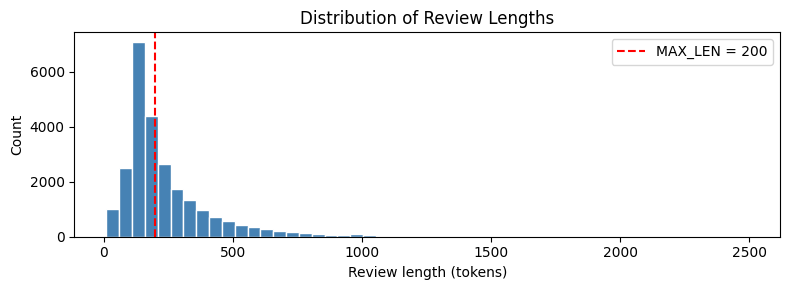

In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────
VOCAB_SIZE    = 10_000   # top N words to keep
MAX_LEN       = 200      # max review length (pad/truncate)
EMBEDDING_DIM = 64       # word vector size
LSTM_UNITS    = 64
BATCH_SIZE    = 128
EPOCHS        = 10

# ── Load IMDB dataset ────────────────────────────────────────────
print("Loading IMDB dataset...")
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Positive (train) : {y_train.sum()} | Negative: {len(y_train) - y_train.sum()}")

# Review length statistics
lengths = [len(x) for x in X_train]
print(f"\nReview length → min: {min(lengths)}, max: {max(lengths)}, mean: {np.mean(lengths):.1f}")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN = {MAX_LEN}')
plt.xlabel('Review length (tokens)')
plt.ylabel('Count')
plt.title('Distribution of Review Lengths')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Pad/truncate sequences to fixed length
X_train_pad = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')

print("X_train shape:", X_train_pad.shape)
print("X_test  shape:", X_test_pad.shape)

# Decode a sample review to verify
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(encoded):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded if i > 2])

print("\n── Sample Review ──")
print(decode_review(X_train[0][:50]), "...")
print("Label:", "Positive ✓" if y_train[0] == 1 else "Negative ✗")

X_train shape: (25000, 200)
X_test  shape: (25000, 200)
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

── Sample Review ──
this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert is an amazing actor and now the same being director father came from the same scottish island as myself so i loved ...
Label: Positive ✓


In [ ]:
def build_model():
    model = Sequential([
        # 1. Embedding layer — converts word indices to dense vectors
        Embedding(input_dim=VOCAB_SIZE,
                  output_dim=EMBEDDING_DIM,
                  input_length=MAX_LEN,
                  name='embedding'),

        # 2. Bidirectional LSTM — reads sequence in both directions
        Bidirectional(LSTM(LSTM_UNITS,
                           return_sequences=True,
                           dropout=0.2,
                           recurrent_dropout=0.2),
                      name='bi_lstm_1'),

        # 3. Second LSTM layer
        LSTM(32, dropout=0.2, name='lstm_2'),

        # 4. Dense hidden layer
        Dense(32, activation='relu', name='dense_hidden'),
        Dropout(0.4),

        # 5. Output layer — sigmoid for binary classification
        Dense(1, activation='sigmoid', name='output')
    ])
    return model

model = build_model()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_1 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

print("Training model...")
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Training model...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.5186 - loss: 0.6899 - val_accuracy: 0.5066 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.5237 - loss: 0.6886 - val_accuracy: 0.5500 - val_loss: 0.6838 - learning_rate: 0.0010
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.5906 - loss: 0.6519 - val_accuracy: 0.5488 - val_loss: 0.7064 - learning_rate: 0.0010
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 968ms/step - accuracy: 0.6246 - loss: 0.6069
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.6536 - loss: 0.5867 - val_accuracy: 0.6672 - val_loss: 0.7235 - learning_rate: 0.0010
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.7940 - loss: 0.4893 - val_accuracy: 0.7720 - val_loss: 0.5392 - learning_rate: 5.0000e-04
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 192s 951ms/step - ac

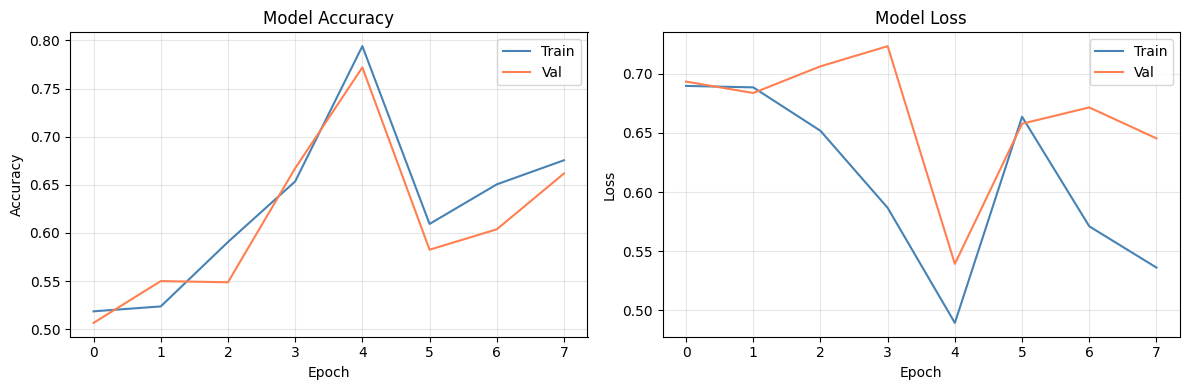

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='coral')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val',   color='coral')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Test Accuracy : 75.88%
Test Loss     : 0.5720

── Classification Report ──
              precision    recall  f1-score   support

    Negative       0.77      0.74      0.75     12500
    Positive       0.75      0.78      0.76     12500

    accuracy                           0.76     25000
   macro avg       0.76      0.76      0.76     25000
weighted avg       0.76      0.76      0.76     25000



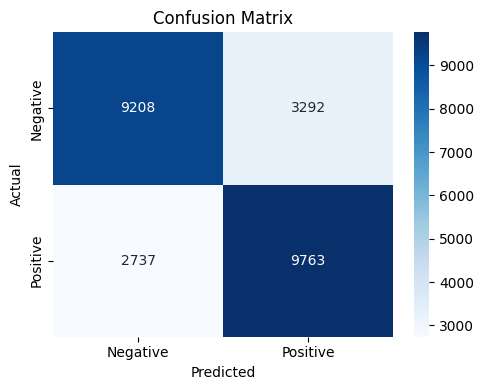

In [ ]:
loss, accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy : {accuracy * 100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

# Predictions
y_pred_prob = model.predict(X_test_pad, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

# Classification report
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
def predict_sentiment(reviews: list[str], threshold: float = 0.5):
    """
    Predict sentiment for a list of raw text reviews.
    Returns a DataFrame with review, score, and label.
    """
    word_index = imdb.get_word_index()

    def encode(text):
        tokens = text.lower().split()
        ids = [word_index.get(w, 2) + 3 for w in tokens]   # 2 = unknown
        ids = [i for i in ids if i < VOCAB_SIZE]
        return ids

    encoded = [encode(r) for r in reviews]
    padded  = pad_sequences(encoded, maxlen=MAX_LEN, padding='post', truncating='post')
    scores  = model.predict(padded, verbose=0).flatten()

    results = pd.DataFrame({
        'Review'   : reviews,
        'Score'    : scores.round(4),
        'Sentiment': ['Positive ✓' if s >= threshold else 'Negative ✗' for s in scores]
    })
    return results


# ── Test it ──────────────────────────────────────────────────────
test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the storyline kept me on the edge of my seat.",
    "Terrible film. Boring plot, bad acting, and a complete waste of time. I couldn't even finish it.",
    "It was okay, nothing special. Some parts were good but overall pretty average.",
    "One of the best movies I have seen in years. Highly recommended to everyone!",
    "Dull, predictable, and painfully slow. The director had no idea what they were doing.",
]

results = predict_sentiment(test_reviews)
print(results.to_string(index=False))

                                                                                                      Review  Score  Sentiment
This movie was absolutely fantastic! The acting was superb and the storyline kept me on the edge of my seat. 0.6881 Positive ✓
            Terrible film. Boring plot, bad acting, and a complete waste of time. I couldn't even finish it. 0.1641 Negative ✗
                              It was okay, nothing special. Some parts were good but overall pretty average. 0.1641 Negative ✗
                                One of the best movies I have seen in years. Highly recommended to everyone! 0.6881 Positive ✓
                       Dull, predictable, and painfully slow. The director had no idea what they were doing. 0.6881 Positive ✓


In [ ]:
# Save
model.save('sentiment_rnn_model.h5')
print("Model saved as sentiment_rnn_model.h5")

# Reload
from tensorflow.keras.models import load_model
loaded_model = load_model('sentiment_rnn_model.h5')
print("Model loaded successfully")

# Quick sanity check
loss, acc = loaded_model.evaluate(X_test_pad[:500], y_test[:500], verbose=0)
print(f"Loaded model accuracy (500 samples): {acc * 100:.2f}%")

Model saved as sentiment_rnn_model.h5
Model loaded successfully
Loaded model accuracy (500 samples): 76.60%
